# Digit Classification on MNIST

The spiral dataset in `trial_jupyter.ipynb` proved the network learns. This notebook
points the same machinery at real handwritten digits.

The layers, activations, loss and optimizer now live in `neuralnet.py`, copied
unchanged from that notebook. The data loader lives in `data/mnist.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The notebooks sit one level below the modules they use, so the project root has to
# go on the path first. Walking up to a marker file rather than hardcoding a parent
# keeps this correct whichever directory the kernel happens to start in.
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "neuralnet.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.mnist import load_mnist
from neuralnet import (
    ActivationReLU,
    ActivationSoftmaxLossCategoricalCrossentropy,
    LayerDense,
    OptimizerSGD,
)

rand_seed = 4

np.random.seed(rand_seed)                # legacy global, used by LayerDense weight init
rng = np.random.default_rng(rand_seed)   # modern generator, used for sampling below

## Loading the data

`load_mnist` defaults to the four original idx archives and parses the binary format
by hand. Passing `source="npz"` fetches a single pre-packed bundle instead. Running
`python data/mnist.py` downloads both and asserts they are identical.

Either way the first call downloads to `data/raw/` and caches; later calls are local.

In [2]:
train_images, train_labels, test_images, test_labels = load_mnist(source="idx")

print(f"train images  {train_images.shape}  {train_images.dtype}")
print(f"train labels  {train_labels.shape}  {train_labels.dtype}")
print(f"test images   {test_images.shape}  {test_images.dtype}")
print(f"test labels   {test_labels.shape}  {test_labels.dtype}")

print()
print(f"pixel range: {train_images.min()} to {train_images.max()}")
print(f"examples per class: {np.bincount(train_labels)}")

train images  (60000, 28, 28)  uint8
train labels  (60000,)  uint8
test images   (10000, 28, 28)  uint8
test labels   (10000,)  uint8

pixel range: 0 to 255
examples per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


## Does it actually look like digits?

The loader already asserts shapes, dtypes and the label range, but nothing so far
proves the pixels are aligned with the labels. A wrong byte offset would still pass
every one of those checks. Eyes on the data settles it.

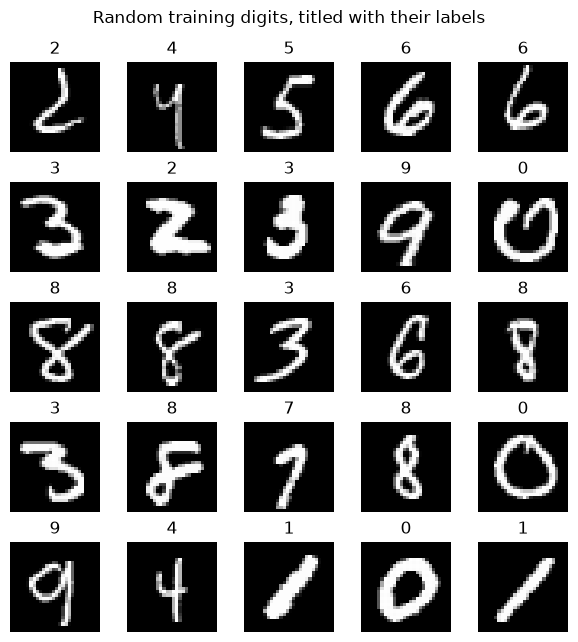

In [3]:
fig, axes = plt.subplots(5, 5, figsize=(6, 6.5))
sample = rng.choice(len(train_images), size=axes.size, replace=False)

for ax, index in zip(axes.flat, sample):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(str(train_labels[index]))
    ax.axis("off")

fig.suptitle("Random training digits, titled with their labels")
fig.tight_layout()
plt.show()

## Preprocessing

Three changes turn the raw arrays into network input.

- **Flatten** each 28x28 image into a 784-long vector, since `LayerDense` takes one row per example.
- **Scale** the 0-255 bytes to roughly -1 to 1. Feeding raw byte values into a layer initialised for small inputs pushes the pre-activations far enough to stall training.
- **Split** off a validation set. The 10,000 test images stay untouched until the very end, so every tuning decision is made against data the final number never sees.

The split is a random slice rather than the tail of the file. MNIST's training set
draws on two different writer populations, so the ordering is not something to trust.

Casting to `float32` halves the footprint of the 60,000 by 784 matrix. The network's
weights are still `float64`, and a mixed matmul silently promotes everything back, so
the layers get cast to match when the network is built.

In [4]:
def preprocess(images):
    flat = images.reshape(len(images), -1).astype(np.float32)
    return (flat - 127.5) / 127.5


X_full = preprocess(train_images)
y_full = train_labels.astype(np.int64)

X_test = preprocess(test_images)
y_test = test_labels.astype(np.int64)

validation_size = 5000

split_rng = np.random.default_rng(rand_seed)
order = split_rng.permutation(len(X_full))     

val_index, train_index = order[:validation_size], order[validation_size:]

X_train, y_train = X_full[train_index], y_full[train_index]
X_val, y_val = X_full[val_index], y_full[val_index]

del X_full, y_full

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:<6} X {str(X.shape):<14} {X.nbytes / 1e6:6.1f} MB    y {y.shape}")

print()
print(f"value range: {X_train.min():.2f} to {X_train.max():.2f}")
print(f"class balance in validation split: {np.bincount(y_val)}")

train  X (55000, 784)    172.5 MB    y (55000,)
val    X (5000, 784)      15.7 MB    y (5000,)
test   X (10000, 784)     31.4 MB    y (10000,)

value range: -1.00 to 1.00
class balance in validation split: [474 531 523 543 433 430 503 527 511 525]
